# 6. Pattern Mining

We mine recurrent combinations of game characteristics and association rules,
and finally test whether the rules can predict `Rating`. Each game becomes a
transaction of categorical items:

* numerical attributes are discretized into readable intervals (publication
  period, complexity, recommended audience, playtime, popularity, player
  capacity);
* binary properties contribute an item only when positive (`Kickstarted`,
  `Reimplementation`, `Has expansions`, `Has alternates`), to avoid patterns
  dominated by absence indicators;
* the multi-label `Cat:*` flags are kept as separate items, so a game can
  carry e.g. both `Strategy` and `War`;
* the target contributes one of `Low rating` / `Medium rating` / `High rating`.

Structural attributes dropped during preparation (`NumExpansions`,
`NumAlternates`, `IsReimplementation`, `Cat:*`) are read back from the raw
table after validating the row alignment on unchanged columns.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/df_clean2.2.csv")
raw = pd.read_csv("../dataset/DM1_game_dataset.csv")
assert (df["YearPublished"] == raw["YearPublished"]).all()
assert (df["Rating"] == raw["Rating"]).all()

In [2]:
cats = ["Thematic", "Strategy", "War", "Family", "CGS", "Abstract", "Party",
        "Childrens"]
pop_low, pop_high = df["PopularityScore"].quantile([1 / 3, 2 / 3])

def make_transaction(r):
    items = [
        "Published before 2006" if r["YearPublished"] < 2006
        else "Published 2006-2015" if r["YearPublished"] <= 2015
        else "Published 2016-2021",
        "Light complexity" if r["AvgGameweight"] < 2
        else "Medium complexity" if r["AvgGameweight"] <= 3
        else "Heavy complexity",
        "Children audience" if r["ComAgeRec"] < 8
        else "Family audience" if r["ComAgeRec"] <= 12
        else "Teen-plus audience",
        "Short duration" if r["ComAvgPlaytime"] <= 30
        else "Medium duration" if r["ComAvgPlaytime"] <= 60
        else "Long duration",
        "Low popularity" if r["PopularityScore"] <= pop_low
        else "Medium popularity" if r["PopularityScore"] <= pop_high
        else "High popularity",
        "Capacity up to 4" if r["MaxPlayers"] <= 4
        else "Capacity 5-8" if r["MaxPlayers"] <= 8
        else "Capacity more than 8",
        f"{r['Rating']} rating",
    ]
    if r["Kickstarted"]:
        items.append("Kickstarted")
    if r["IsReimplementation"]:
        items.append("Reimplementation")
    if r["NumExpansions"] > 0:
        items.append("Has expansions")
    if r["NumAlternates"] > 0:
        items.append("Has alternates")
    items += [c for c in cats if r[f"Cat:{c}"]]
    return items

full = pd.concat([df, raw[["IsReimplementation", "NumExpansions", "NumAlternates"]
                          + [f"Cat:{c}" for c in cats]]], axis=1)
transactions = [make_transaction(r) for r in full.to_dict("records")]
print(len(transactions), "transactions,",
      round(np.mean([len(t) for t in transactions]), 2), "items per transaction")

21925 transactions, 8.5 items per transaction


In [3]:
te = TransactionEncoder()
onehot = pd.DataFrame(te.fit(transactions).transform(transactions),
                      columns=te.columns_)

## 6.1 Frequent pattern extraction

We extract itemsets of length 2-4 with minimum support from 2% to 20%, using
both Apriori and FP-Growth to cross-check the results.

In [4]:
def frequent(min_sup, algo=fpgrowth):
    its = algo(onehot, min_support=min_sup, use_colnames=True, max_len=4)
    its["length"] = its["itemsets"].str.len()
    return its

def closed_maximal(its):
    sets = list(zip(its["itemsets"], its["support"]))
    closed, maximal = [], []
    for s, sup in sets:
        supersets = [t for t, _ in sets if s < t]
        closed.append(not any(tsup == sup for t, tsup in sets if s < t))
        maximal.append(not supersets)
    return its.assign(closed=closed, maximal=maximal)

counts = []
for sup in [0.02, 0.05, 0.10, 0.15, 0.20]:
    its = closed_maximal(frequent(sup).query("length >= 2"))
    counts.append([sup, len(its), its["closed"].sum(), its["maximal"].sum()])
counts = pd.DataFrame(counts, columns=["min support", "frequent", "closed",
                                       "maximal"])
counts

,min support,frequent,closed,maximal
0,0.02,2969,2969,1691
1,0.05,755,755,373
2,0.10,189,189,122
3,0.15,65,65,53
4,0.20,20,20,20


Apriori and FP-Growth agree at 5%: True


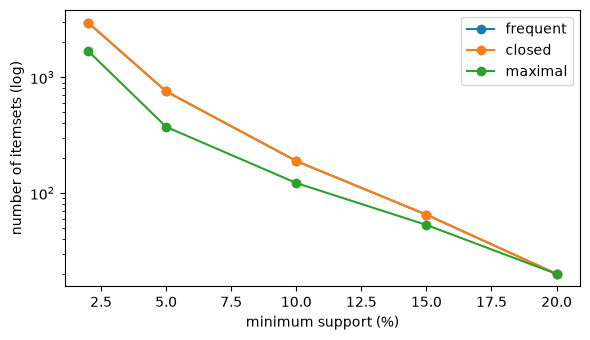

In [5]:
same = frequent(0.05).query("length >= 2")["itemsets"]
same_ap = frequent(0.05, apriori).query("length >= 2")["itemsets"]
print("Apriori and FP-Growth agree at 5%:", set(same) == set(same_ap))

plt.figure(figsize=(6, 3.5))
for col in ["frequent", "closed", "maximal"]:
    plt.plot(counts["min support"] * 100, counts[col], "o-", label=col)
plt.yscale("log")
plt.xlabel("minimum support (%)")
plt.ylabel("number of itemsets (log)")
plt.legend()
plt.tight_layout()
plt.show()

The search space shrinks rapidly with the threshold. 2% keeps thousands of
largely redundant itemsets, while 20% only retains a handful of broad
combinations: 5% is a good compromise for qualitative inspection, and we look
at closed itemsets since they carry all the support information.

In [6]:
its5 = closed_maximal(frequent(0.05).query("length >= 2"))
closed5 = its5[its5["closed"]].sort_values("support", ascending=False)
closed5["games"] = (closed5["support"] * len(onehot)).round().astype(int)
closed5[["itemsets", "games", "support"]].head(10)

,itemsets,games,support
30,"frozenset({Family audience, Capacity up to 4})",6957,0.317309
34,"frozenset({Short duration, Light complexity})",6860,0.312885
710,"frozenset({Family audience, Medium complexity})",6183,0.282007
249,"frozenset({Family audience, Medium rating})",6148,0.280410
31,"frozenset({Family audience, Light complexity})",5573,0.254185
275,"frozenset({Family audience, Capacity 5-8})",5495,0.250627
712,"frozenset({Capacity up to 4, Medium complexity})",5276,0.240639
251,"frozenset({Capacity up to 4, Medium rating})",5251,0.239498
132,"frozenset({Low rating, Light complexity})",5123,0.233660
35,"frozenset({Family audience, Short duration})",5089,0.232109


In [7]:
picks = [{"Light complexity", "Short duration"},
         {"Family audience", "Medium complexity"},
         {"Published 2016-2021", "High rating"},
         {"War", "Long duration"},
         {"Has expansions", "High popularity"}]
closed5[closed5["itemsets"].isin([frozenset(p) for p in picks])][
    ["itemsets", "games", "support"]]

,itemsets,games,support
34,"frozenset({Short duration, Light complexity})",6860,0.312885
710,"frozenset({Family audience, Medium complexity})",6183,0.282007
213,"frozenset({High popularity, Has expansions})",3282,0.149692
412,"frozenset({Published 2016-2021, High rating})",2925,0.133409
616,"frozenset({Long duration, War})",2660,0.121323


The most frequent patterns confirm plausible domain profiles: short games tend
to be light, medium-complexity games often target a family audience. More
specific combinations survive too, e.g. long war games, recent highly rated
games, and games with expansions being highly popular.

## 6.2 Association rules

Rules are generated for several (support, confidence) combinations and
evaluated with support, confidence and lift; lift tells apart a genuinely
enriched consequent from a merely frequent one.

In [8]:
def rules_for(min_sup, min_conf):
    r = association_rules(frequent(min_sup), metric="confidence",
                          min_threshold=min_conf)
    return r[r["support"] >= min_sup]

grid = pd.DataFrame(
    {f"conf {c:.0%}": [len(rules_for(s, c)) for s in [0.02, 0.05, 0.10, 0.15, 0.20]]
     for c in [0.5, 0.6, 0.7, 0.8, 0.9]},
    index=[f"sup {s:.0%}" for s in [0.02, 0.05, 0.10, 0.15, 0.20]])
grid

,conf 50%,conf 60%,conf 70%,conf 80%,conf 90%
sup 2%,4181,2243,1161,539,129
sup 5%,925,480,242,102,15
sup 10%,165,78,38,12,2
sup 15%,61,24,10,3,0
sup 20%,21,9,4,0,0


480 rules | median confidence: 70.1 % | median lift: 1.59


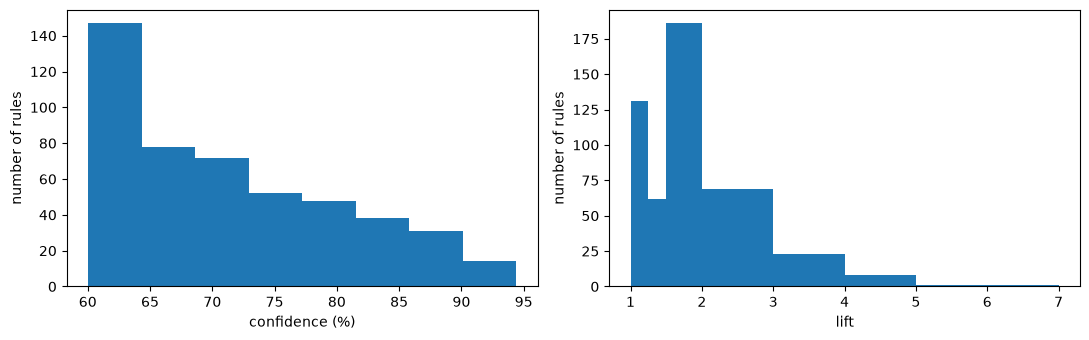

In [9]:
rules = rules_for(0.05, 0.60)
print(len(rules), "rules | median confidence:",
      round(rules["confidence"].median() * 100, 1),
      "% | median lift:", round(rules["lift"].median(), 2))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(rules["confidence"] * 100, bins=8)
axes[0].set(xlabel="confidence (%)", ylabel="number of rules")
axes[1].hist(rules["lift"], bins=[1, 1.25, 1.5, 2, 3, 4, 5, 7])
axes[1].set(xlabel="lift", ylabel="number of rules")
plt.tight_layout()
plt.show()

In [10]:
(rules.sort_values("lift", ascending=False)
 [["antecedents", "consequents", "support", "confidence", "lift"]]
 .head(10).round(3))

,antecedents,consequents,support,confidence,lift
380,"frozenset({Long duration, Capacity up to 4, Pu...",frozenset({War}),0.061,0.815,5.061
353,"frozenset({Long duration, Capacity up to 4, Me...",frozenset({War}),0.051,0.738,4.586
364,"frozenset({Long duration, Capacity up to 4, Te...",frozenset({War}),0.065,0.728,4.521
378,"frozenset({Teen-plus audience, Published befor...",frozenset({War}),0.051,0.693,4.307
238,"frozenset({War, Heavy complexity})","frozenset({Long duration, Capacity up to 4})",0.052,0.722,4.278
229,"frozenset({Teen-plus audience, High rating})",frozenset({Heavy complexity}),0.053,0.640,4.213
367,"frozenset({Teen-plus audience, War})","frozenset({Long duration, Capacity up to 4})",0.065,0.693,4.108
226,"frozenset({Long duration, High rating})",frozenset({Heavy complexity}),0.070,0.613,4.032
356,"frozenset({Medium popularity, War})","frozenset({Long duration, Capacity up to 4})",0.051,0.675,4.001
245,"frozenset({Long duration, Teen-plus audience})",frozenset({Heavy complexity}),0.077,0.605,3.979


At support 5% / confidence 60% the pool is compact but still expressive. The
strongest rules associate long, older, low-capacity games with the war
category; recent long games with high ratings; strategy games having alternate
versions with high popularity; and older light low-popularity games with low
ratings. These are associations, not causal statements.

## 6.3 Exploiting rules to predict Rating

80/20 stratified split; rules whose consequent is a rating item are mined on
the training set only. At test time the rating items are removed from each
transaction; among the rules covering a game we apply the one with the highest
confidence (then lift, then support), falling back to the training majority
class for uncovered games.

In [11]:
rating_items = {"Low rating", "Medium rating", "High rating"}
train_idx, test_idx = train_test_split(np.arange(len(transactions)),
                                       test_size=0.2, random_state=42,
                                       stratify=df["Rating"])
onehot_train = onehot.iloc[train_idx]
test_sets = [set(transactions[i]) - rating_items for i in test_idx]
y_test = df["Rating"].iloc[test_idx].values
majority = df["Rating"].iloc[train_idx].mode()[0]

def rating_rules(min_sup, min_conf):
    its = fpgrowth(onehot_train, min_support=min_sup, use_colnames=True, max_len=4)
    r = association_rules(its, metric="confidence", min_threshold=min_conf)
    r = r[(r["consequents"].str.len() == 1)
          & r["consequents"].apply(lambda c: set(c) <= rating_items)
          & r["antecedents"].apply(lambda a: not (set(a) & rating_items))]
    return r.sort_values(["confidence", "lift", "support"], ascending=False)

def predict(rules_df):
    ants = [set(a) for a in rules_df["antecedents"]]
    cons = [next(iter(c)).replace(" rating", "") for c in rules_df["consequents"]]
    preds, covered = [], []
    for t in test_sets:
        hit = next((c for a, c in zip(ants, cons) if a <= t), None)
        covered.append(hit is not None)
        preds.append(hit if hit is not None else majority)
    return np.array(preds), np.array(covered)

rows = []
for min_sup, min_conf in [(0.02, 0.6), (0.02, 0.7), (0.05, 0.5), (0.05, 0.6),
                          (0.05, 0.7), (0.05, 0.8)]:
    rr = rating_rules(min_sup, min_conf)
    preds, covered = predict(rr)
    rows.append([f"{min_sup:.0%}", f"{min_conf:.0%}", len(rr),
                 f"{covered.mean():.2%}",
                 f"{(preds[covered] == y_test[covered]).mean():.2%}"
                 if covered.any() else "-",
                 f"{(preds == y_test).mean():.2%}"])
pd.DataFrame(rows, columns=["min sup", "min conf", "rating rules", "coverage",
                            "covered accuracy", "overall accuracy"])

,min sup,min conf,rating rules,coverage,covered accuracy,overall accuracy
0,2%,60%,151,86.41%,59.75%,58.75%
1,2%,70%,57,48.62%,65.90%,59.18%
2,5%,50%,97,100.00%,57.99%,57.99%
3,5%,60%,22,66.43%,61.45%,58.04%
4,5%,70%,8,23.56%,73.86%,55.74%
5,5%,80%,1,6.43%,84.04%,48.46%


In [12]:
print("majority baseline:",
      f"{(y_test == majority).mean():.2%}")

majority baseline: 43.99%


In [13]:
from sklearn.metrics import confusion_matrix

preds, covered = predict(rating_rules(0.05, 0.6))
cm = confusion_matrix(y_test, preds, labels=["Low", "Medium", "High"])
pd.DataFrame(cm, index=["Low", "Medium", "High"],
             columns=["Low", "Medium", "High"])

,Low,Medium,High
Low,954,461,34
Medium,513,1204,212
High,81,539,387


The 5% / 60% configuration keeps a compact, readable rule set covering about
half of the held-out games, with a clear improvement over the majority
baseline. Lowering the support raises coverage and overall accuracy a little,
but at the price of an order of magnitude more rules and much lower
interpretability. The goal here is not to compete with the supervised
classifiers: it is to show that a small set of interpretable associations can
be operationalized, exposing exactly which profiles drive each prediction.